### **가설 검증 3: PM 규제 이후 공유 자전거(따릉이) 이용량은 변화하였는가? (대체 효과)**

#### 강력한 견인 조치와 단속(2021년 7월 견인 조치 시행 기준)으로 인해 킥보드 이용자들이 대체 수단인 '따릉이'로 이동했는지 확인합니다.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
import os

In [3]:
# 시각화 시 한글 폰트 깨짐 방지 (Windows: Malgun Gothic, Mac: AppleGothic)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 경고 무시
import warnings
warnings.filterwarnings('ignore')

# 전처리 데이터셋 경로 정의
BASE_PATH = '../../data/data-preprocessing'

****

#### **데이터 불러오기**
##### 가설 검증에 필요한 데이터를 불러옵니다.

In [6]:
# 따릉이 이용건수 시계열 데이터 준비
df_bike = pd.read_csv(os.path.join(BASE_PATH, "서울시 따릉이 월별 이용정보 통합", "따릉이_월별_이용정보_통합.csv"), 
                      encoding='utf-8')
df_bike_monthly = df_bike.groupby('연월')['이용건수'].sum().reset_index()
df_bike_monthly['연월'] = pd.to_datetime(df_bike_monthly['연월'])

# PM 견인 현황 데이터 불러오기
# 견인 조치는 2021년 7월부터 시작되었으므로 과거 데이터가 없음
# 따라서 견인건수 자체는 절대량을 사용하되, 따릉이의 YoY 증감량과 비교
df_tow = pd.read_csv(os.path.join(BASE_PATH, "서울시 전동킥보드 견인 현황", "서울특별시_전동킥보드_견인_현황_202107~202512.csv"), encoding='utf-8')
df_tow = df_tow.rename(columns={'신고월': '연월'})
df_tow_monthly_total = df_tow.groupby('연월').size().reset_index(name='견인건수')

공유 자전거(따릉이)는 계절에 따라 이용률의 차이가 극심합니다. 이러한 계절성 요인을 분석에 반영하여 결과의 신뢰도를 높입니다.

In [7]:
# 12개월(1년) 전 데이터와 비교하여 증감량 계산 (계절성 통제)
df_bike_monthly['이용건수_YoY_diff'] = df_bike_monthly['이용건수'].diff(periods=12)

# 결측치(최초 1년 데이터) 제거
df_bike_yoy = df_bike_monthly.dropna(subset=['이용건수_YoY_diff']).copy()

# 명시적으로 datetime 변환 다시 한 번 수행
df_bike_yoy['연월'] = pd.to_datetime(df_bike_yoy['연월'])
df_tow_monthly_total['연월'] = pd.to_datetime(df_tow_monthly_total['연월'])

In [8]:
print('따릉이 데이터 크기: ', df_bike_monthly.shape)
display(df_bike_monthly.head())
print('견인 데이터 크기: ', df_tow_monthly_total.shape)
display(df_tow_monthly_total.head())

따릉이 데이터 크기:  (96, 3)


,연월,이용건수,이용건수_YoY_diff
0,2018-01-01,164320,NaN
1,2018-02-01,168687,NaN
2,2018-03-01,462584,NaN
3,2018-04-01,668474,NaN
4,2018-05-01,929061,NaN


견인 데이터 크기:  (54, 2)


,연월,견인건수
0,2021-07-01,1356
1,2021-08-01,2946
2,2021-09-01,4066
3,2021-10-01,3642
4,2021-11-01,4275


****

#### **T-Test**
##### 견인 규제 전후 따릉이 이용 증감량을 비교하여 통계적 유의성을 확인합니다.

In [11]:
# 2021년 7월 기준으로 분리 (계절성이 통제된 YoY 증감량 기준)
before_tow_yoy = df_bike_yoy[df_bike_yoy['연월'] < '2021-07-01']['이용건수_YoY_diff']
after_tow_yoy = df_bike_yoy[df_bike_yoy['연월'] >= '2021-07-01']['이용건수_YoY_diff']

t_stat_bike, p_val_bike = stats.ttest_ind(before_tow_yoy, after_tow_yoy, equal_var=False)

print("=== [계절성 통제] 견인 규제 전후 따릉이 이용 증감량(YoY) 비교 (T-test) ===")
print(f"견인 조치 이전(21.07 이전) 월평균 따릉이 증감량: {before_tow_yoy.mean():,.0f} 건 (작년 대비 증가폭)")
print(f"견인 조치 이후(21.07 이후) 월평균 따릉이 증감량: {after_tow_yoy.mean():,.0f} 건 (작년 대비 증가폭)")
print(f"T-test 검정통계량: {t_stat_bike:.4f}, p-value: {p_val_bike:.4f}\n")

=== [계절성 통제] 견인 규제 전후 따릉이 이용 증감량(YoY) 비교 (T-test) ===
견인 조치 이전(21.07 이전) 월평균 따릉이 증감량: 559,079 건 (작년 대비 증가폭)
견인 조치 이후(21.07 이후) 월평균 따릉이 증감량: 195,038 건 (작년 대비 증가폭)
T-test 검정통계량: 3.2861, p-value: 0.0015



규제 이전 시기의 월평균 따릉이 증감량 성장폭보다 규제 이후 시기의 성장폭이 더 낮았습니다. p-value 값은 0.0015로, 통계적으로 매우 유의함을 알 수 있습니다.

****

#### **상관관계 분석 및 시각화**
피어슨 상관관계 분석을 통해 견인이 강하게 이루어진 달일수록 따릉이 이용량이 작년에 비해 높에 뛰어올랐는지 확인합니다.

In [12]:
# 견인 건수와 따릉이 이용건수 증감량 병합
df_merge_bike_tow = pd.merge(df_bike_yoy, df_tow_monthly_total, on='연월', how='inner')

corr_bike, p_bike = pearsonr(df_merge_bike_tow['견인건수'], df_merge_bike_tow['이용건수_YoY_diff'])

print("=== [계절성 통제] PM 견인 건수와 따릉이 이용 증감량(YoY) 상관관계 ===")
print(f"상관계수(r): {corr_bike:.4f}")
print(f"p-value: {p_bike:.4f}")

=== [계절성 통제] PM 견인 건수와 따릉이 이용 증감량(YoY) 상관관계 ===
상관계수(r): -0.3536
p-value: 0.0087


p-value가 기준치인 0.05보다 작게 나옴으로써, 통계적으로 믿을 수 있는 유의미한 결과임을 알 수 있습니다.

예상과 달리, 오히려 음(-)의 상관관계가 도출되었습니다.

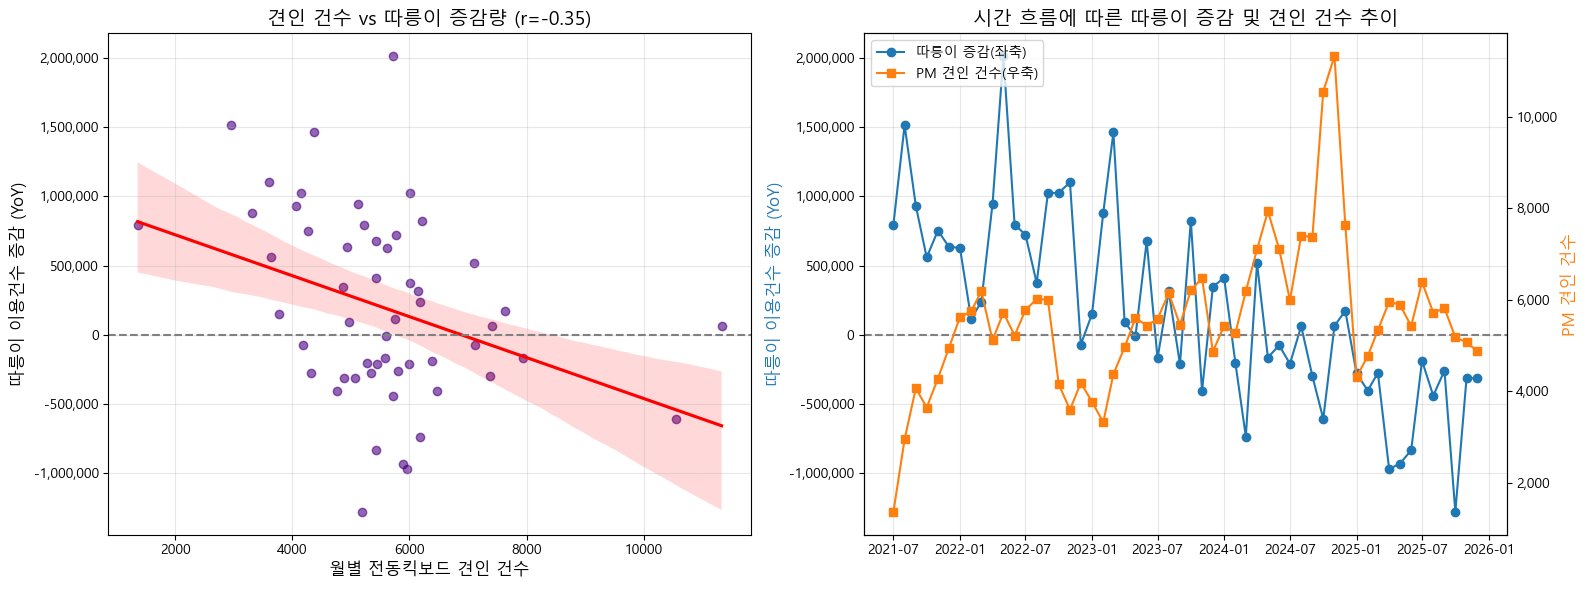

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 그래프 1: 기존 산점도 (견인 건수 vs 따릉이 증감량)
sns.regplot(data=df_merge_bike_tow, x='견인건수', y='이용건수_YoY_diff', 
            scatter_kws={'alpha':0.6, 'color':'indigo'}, line_kws={'color':'red'}, ax=ax1)

ax1.set_title(f'견인 건수 vs 따릉이 증감량 (r={corr_bike:.2f})', fontsize=14)
ax1.set_xlabel('월별 전동킥보드 견인 건수', fontsize=12)
ax1.set_ylabel('따릉이 이용건수 증감 (YoY)', fontsize=12)
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax1.axhline(0, color='grey', linestyle='--') 
ax1.grid(True, alpha=0.3)


# 그래프 2: 시간 흐름에 따른 견인 건수와 따릉이 증감량 추이 (듀얼 축)
ax2_twin = ax2.twinx()

# 따릉이 이용 증감량 라인 (파란색 계열)
line1 = ax2.plot(df_merge_bike_tow['연월'], df_merge_bike_tow['이용건수_YoY_diff'], 
                 color='#1f77b4', marker='o', label='따릉이 증감(좌축)')
# 전동킥보드 견인 건수 라인 (주황색 계열)
line2 = ax2_twin.plot(df_merge_bike_tow['연월'], df_merge_bike_tow['견인건수'], 
                      color='#ff7f0e', marker='s', label='PM 견인 건수(우축)')

ax2.set_title('시간 흐름에 따른 따릉이 증감 및 견인 건수 추이', fontsize=14)
ax2.set_ylabel('따릉이 이용건수 증감 (YoY)', color='#1f77b4', fontsize=12)
ax2_twin.set_ylabel('PM 견인 건수', color='#ff7f0e', fontsize=12)

ax2.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax2_twin.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax2.axhline(0, color='grey', linestyle='--') 
ax2.grid(True, alpha=0.3)

# 범례 통합
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.show()

- **견인 건수 vs 따릉이 증감량 (r=-0.35)**
  - 산점도 그래프의 빨간색 회귀선을 보면, **우하향 형태**를 보이고 있습니다.
  - 즉, 월별 전동킥보드 견인 건수가 늘어날수록, 따릉이 이용건수는 감소하는 음의 상관관계(-0.35)를 보이고 있습니다.
- **시간 흐름에 따른 따릉이 증감 및 견인 건수 추이**
  - 2021년 하반기(견인 조치 본격화 시점)부터 **우측 축을 따르는 주황색 선(PM 견인 건수)은 가파르게 우상향**하며 치솟습니다. 반면, **좌측 축을 따르는 파란색 선(따릉이 이용 증감량)은 같은 시기부터 0선(회색 점선)을 향해 우하향**하는 모습을 보이고 있습니다.
    - 이는, 앞서 계산한 피어슨 상관계수가 실제로 어떤 양상으로 나타나고 있는지 시각적으로 보여줍니다.
  - 만약 "킥보드 타기가 힘들어져서 사람들이 따릉이로 넘어갔다"는 대체 효과가 사실이었다면, 주황색 선이 올라갈 때 파란색 선도 함께 튀어 오르는 동반 상승 현상이 나타났어야 합니다. **하지만, 그래프는 그 반대를 보여주고 있습니다.**
  - 파란색 선(따릉이 증감)이 0선 근처로 수렴하거나 마이너스로 떨어지는 시점은 `[가설검증2_코로나_PM사고건수]`에서 확인했던 '거리두기 해제 및 대중교통 정상화 시기'와도 맞물립니다.

****

****

### **소결론**
- 시간 흐름에 따른 듀얼 축 분석 결과, 전동킥보드 견인 조치가 강화되는 시점에 따릉이 이용건수 성장세는 오히려 가파르게 둔화되는 역상관을 보였습니다.
- 이는 PM에 대한 강력한 규제가 경쟁 수단인 공공자전거의 수요 증가(대체 효과)로 이어지지 않음을 입증합니다. 오히려 앞선 코로나19 거리두기 분석과 종합해 볼 때, 이 시기의 따릉이 수요 감소는 팬데믹 종식으로 인한 '공유 모빌리티 시장 전반의 거품 붕괴 및 대중교통으로의 회귀'라는 거시적 요인이 작용한 결과로 보아야 타당합니다.